# EXPLORATORY DATA ANALYSIS

Get the desired features from the dataset, visualize and explore the features, applying any cleaning techniques before using the dataset.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the dataset and see column names and their types.

df = pd.read_csv('../Data/Lung_and_Bronchus.csv')

print(df.info())
print(df.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 579970 entries, 0 to 579969
Data columns (total 20 columns):
 #   Column                                                  Non-Null Count   Dtype
---  ------                                                  --------------   -----
 0   Sex                                                     579970 non-null  str  
 1   Site recode ICD-O-3/WHO 2008                            579970 non-null  str  
 2   Behavior code ICD-O-3                                   579970 non-null  str  
 3   Histologic Type ICD-O-3                                 579970 non-null  int64
 4   RX Summ--Surg Prim Site (1998+)                         579970 non-null  int64
 5   Radiation recode                                        579970 non-null  str  
 6   Chemotherapy recode (yes, no/unk)                       579970 non-null  str  
 7   RX Summ--Scope Reg LN Sur (2003+)                       184846 non-null  str  
 8   Time from diagnosis to treatment in days recode        

- Drop the below columns as they don't contain any predictive value

In [41]:
df.drop(columns=['Site recode ICD-O-3/WHO 2008', 'Behavior code ICD-O-3'])

,Sex,Histologic Type ICD-O-3,RX Summ--Surg Prim Site (1998+),Radiation recode,"Chemotherapy recode (yes, no/unk)",RX Summ--Scope Reg LN Sur (2003+),Time from diagnosis to treatment in days recode,Survival months,Visceral and Parietal Pleural Invasion Recode (2010+),SEER Combined Mets at DX-lung (2010+),SEER cause-specific death classification,Age recode with <1 year olds and 90+,Tumor Size Over Time Recode (1988+),Regional nodes examined (1988+),Regional nodes positive (1988+),Separate Tumor Nodules Ipsilateral Lung Recode (2010+),"Race recode (W, B, AI, API)",Year of diagnosis
0,Male,8140,33,None/Unknown,Yes,4 or more regional lymph nodes removed,058,0047,PL1 or PL2; Invasion of visceral pleura presen...,No,Alive or dead of other cause,65-69 years,070,16,9,None; No intrapulmonary mets; Foci in situ/min...,White,2018
1,Female,8010,0,None/Unknown,No/Unknown,NaN,Unable to calculate,0003,Not documented; No resection of primary; Not a...,No,Alive or dead of other cause,75-79 years,030,0,98,None; No intrapulmonary mets; Foci in situ/min...,White,2011
2,Female,8140,0,None/Unknown,No/Unknown,NaN,Unable to calculate,0029,Not documented; No resection of primary; Not a...,No,Dead (attributable to this cancer dx),65-69 years,030,0,98,None; No intrapulmonary mets; Foci in situ/min...,Black,2010
3,Female,8140,0,Beam radiation,Yes,NaN,019,0027,Not documented; No resection of primary; Not a...,No,Dead (attributable to this cancer dx),65-69 years,109,0,98,Separate nodules of same hist type in ipsilate...,White,2016
4,Female,8041,0,None/Unknown,No/Unknown,NaN,Unable to calculate,0000,Not documented; No resection of primary; Not a...,No,Dead (attributable to this cancer dx),65-69 years,Unknown or size unreasonable (includes any tum...,0,98,Not documented; Primary tumor is in situ; Not ...,Black,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579965,Female,8000,99,None/Unknown,No/Unknown,Unknown or not applicable,Unable to calculate,Unknown,Not documented; No resection of primary; Not a...,Unknown,Dead (attributable to this cancer dx),65-69 years,Unknown or size unreasonable (includes any tum...,99,99,Not documented; Primary tumor is in situ; Not ...,Black,2021
579966,Female,8000,99,None/Unknown,No/Unknown,Unknown or not applicable,Unable to calculate,Unknown,Not documented; No resection of primary; Not a...,Unknown,Dead (attributable to this cancer dx),80-84 years,Unknown or size unreasonable (includes any tum...,99,99,Not documented; Primary tumor is in situ; Not ...,White,2021
579967,Female,8000,99,None/Unknown,No/Unknown,Unknown or not applicable,Unable to calculate,Unknown,Not documented; No resection of primary; Not a...,Unknown,Dead (attributable to this cancer dx),85-89 years,Unknown or size unreasonable (includes any tum...,99,99,Not documented; Primary tumor is in situ; Not ...,White,2021
579968,Male,8000,99,None/Unknown,No/Unknown,Unknown or not applicable,Unable to calculate,Unknown,Not documented; No resection of primary; Not a...,Unknown,Dead (attributable to this cancer dx),65-69 years,Unknown or size unreasonable (includes any tum...,99,99,Not documented; Primary tumor is in situ; Not ...,White,2021


### Missing Values
In the below cell, we see that the 2 features *RX Summ--Scope Reg LN Sur (2003+)* and *SEER Combined Mets at DX-lung (2010+)* both contain 'NaN' values. These 'NaN' values are substitutions for blank cells/entries. It's important to consider that these blank values are separate from the entries representing 'unknown' or 'N/A', and thus I feel that it would be incorrect to simply group these values together. For the former feature mentioned, I have elected to remove the feature entirely, as over 68% of entries are blank, and this combined with a lack of documentation on why entries are left blank concerns me with regards to its reliability. For *SEER Combined Mets at DX-lung (2010+)*, I decided to remove the data entries containing those blank entries, as only a very small portion of entries have that blank entry.

In [42]:
## Handle missing values in each category

#see unqiue values at column with missing values
print(df['RX Summ--Scope Reg LN Sur (2003+)'].unique())
print(df['SEER Combined Mets at DX-lung (2010+)'].unique())

#Handle missing values
df = df.dropna(subset=['SEER Combined Mets at DX-lung (2010+)'])
df = df.drop(columns='RX Summ--Scope Reg LN Sur (2003+)')

<StringArray>
[                    '4 or more regional lymph nodes removed',
                                                          nan,
           'Biopsy or aspiration of regional lymph node, NOS',
                        '1 to 3 regional lymph nodes removed',
                                  'Unknown or not applicable',
             'Number of regional lymph nodes removed unknown',
                                 'Sentinel lymph node biopsy',
 'Sentinel node biopsy and lym nd removed same/unstated time',
    'Sentinel node biopsy and lym nd removed different times']
Length: 9, dtype: str
<StringArray>
['No', 'Yes', 'Unknown', nan]
Length: 4, dtype: str


### Data Transformation
- Convert the below features from string values to number values (Int64). This makes them easier to work with, and prepares them for future transformation/preprocessing. Before handling unknown/missing values, I will visualize the variables. Doing so will allow to better understand the distribution of known values for each feature before deciding on how to impute them.

- For the age groups, I elect to use the midpoint of each age group to preserve the distance between each age group.

In [43]:
print(df.iloc[:, [7, 8]].head(10))

col = 'Time from diagnosis to treatment in days recode'
df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

df['Survival months'] = pd.to_numeric(df['Survival months'], errors="coerce").astype("Int64")

col = 'Tumor Size Over Time Recode (1988+)'
df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

  Time from diagnosis to treatment in days recode Survival months
0                                             058            0047
1                             Unable to calculate            0003
2                             Unable to calculate            0029
3                                             019            0027
4                             Unable to calculate            0000
5                                             039            0052
6                                             045            0012
7                                             023            0047
8                                             148            0016
9                             Unable to calculate            0000


In [44]:
print(df.iloc[:, 12].unique())

def age_to_midpoint(age):
    lower = int(age[:2])

    if lower > 0:
        return lower + 2
    return lower

    
col = 'Age recode with <1 year olds and 90+'

df[col] = df[col].apply(age_to_midpoint)

df[col].unique()


<StringArray>
['65-69 years', '75-79 years', '80-84 years', '85-89 years', '55-59 years',
 '60-64 years',   '90+ years', '70-74 years', '50-54 years', '45-49 years',
 '40-44 years', '35-39 years', '30-34 years', '25-29 years', '20-24 years',
 '15-19 years', '10-14 years',    '00 years', '05-09 years', '01-04 years']
Length: 20, dtype: str


array([67, 77, 82, 87, 57, 62, 92, 72, 52, 47, 42, 37, 32, 27, 22, 17, 12,
        0,  7,  3])

### Univariate Analysis

- Visualize the features individually to better understand which values are most common/rare, skewness, etc.

In [45]:
categorical = [
    'Sex',
    'Histologic Type ICD-O-3',
    'RX Summ--Surg Prim Site (1998+)',
    'Radiation recode',
    'Chemotherapy recode (yes, no/unk)',
    'Visceral and Parietal Pleural Invasion Recode (2010+)',
    'SEER Combined Mets at DX-lung (2010+)',
    'SEER cause-specific death classification',
    'Separate Tumor Nodules Ipsilateral Lung Recode (2010+)',
    'Race recode (W, B, AI, API)'
]

numerical = [
    'Time from diagnosis to treatment in days recode',
    'Survival months',
    'Tumor Size Over Time Recode (1988+)',
    'Regional nodes examined (1988+)',
    'Regional nodes positive (1988+)',
    'Year of diagnosis'
]

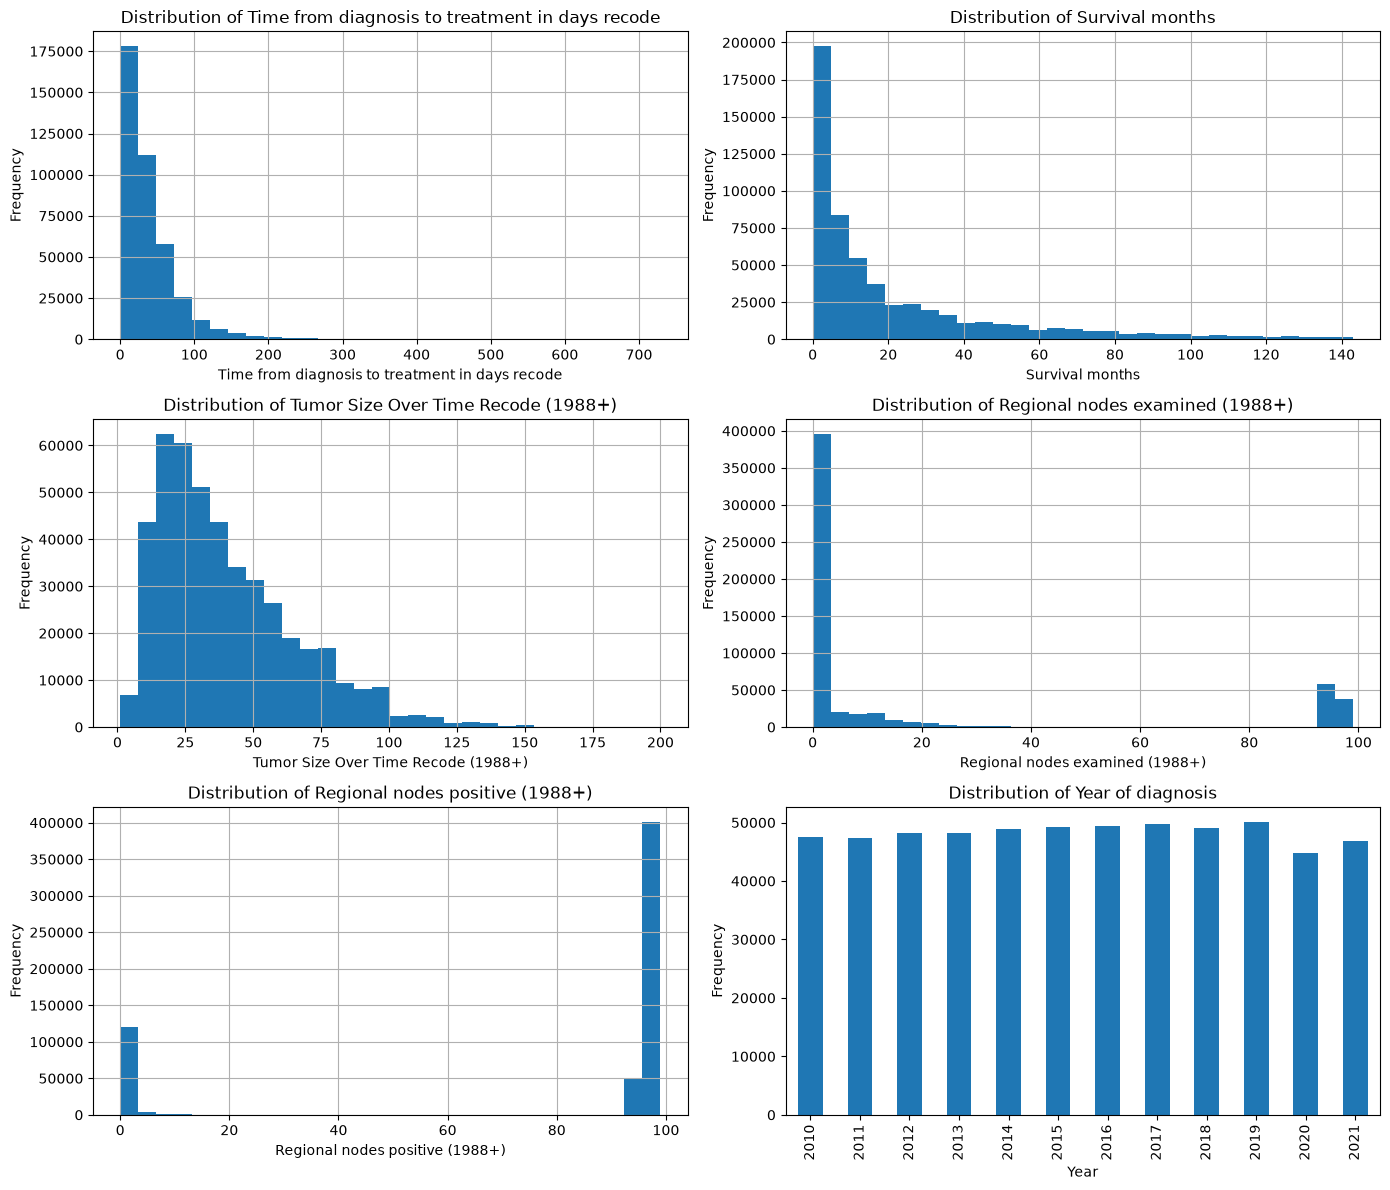

In [48]:


fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, col in zip(axes, numerical):

    if col == 'Year of diagnosis':
        df[col].value_counts().sort_index().plot(
            kind='bar',
            ax=ax
        )
        ax.set_xlabel('Year')

    else:
        df[col].hist(
            bins=30,
            ax=ax
        )
        ax.set_xlabel(col)

    ax.set_title(f'Distribution of {col}')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()